In [11]:
import sys
sys.path.insert(0, '..')   # để import được src/ từ trong notebooks/

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_inspector import DataInspector
from src.visualizer     import AutoVisualizer

## 1. Load Data

In [12]:
# Đường dẫn tương đối từ thư mục gốc project
# Nếu chạy từ trong notebooks/ thì dùng '../data/healthcare_dataset.csv'
df = pd.read_csv('../data/healthcare_dataset.csv')
df.head(10)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
5,EMILY JOHNSOn,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,389,Urgent,2023-12-24,Ibuprofen,Normal
6,edwArD EDWaRDs,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.872345,389,Emergency,2020-11-15,Paracetamol,Inconclusive
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal
9,ChRISTopher BerG,58,Female,AB-,Cancer,2021-05-23,Heather Day,Padilla-Walker,UnitedHealthcare,19784.631062,249,Elective,2021-06-22,Paracetamol,Inconclusive


## 2. Data Inspection
Dùng `DataInspector` để kiểm tra toàn diện: shape, missing, dup, outlier, target...

In [21]:
inspector = DataInspector(df, target_col='Test Results')
inspector.run()

  SHAPE & MEMORY
  Rows   : 55,500
  Columns: 15
  Memory : 38.33 MB

MISSING VALUES
Không có missing values!
  DUPLICATE ROWS
    534 rows bị trùng → dùng df.drop_duplicates()
  COLUMN TYPES
  Name                      object      (49,992 unique)
  Age                       int64       (77 unique)
  Gender                    object      (2 unique)
  Blood Type                object      (8 unique)
  Medical Condition         object      (6 unique)
  Date of Admission         object      (1,827 unique)
  Doctor                    object      (40,341 unique)
  Hospital                  object      (39,876 unique)
  Insurance Provider        object      (5 unique)
  Billing Amount            float64     (50,000 unique)
  Room Number               int64       (400 unique)
  Admission Type            object      (3 unique)
  Discharge Date            object      (1,856 unique)
  Medication                object      (5 unique)
  Test Results              object      (3 unique)
  NUMERIC CO

In [17]:
# Giá trị âm trong Billing Amount
print(f"Billing Amount âm: {(df['Billing Amount'] < 0).sum()} rows")
print(f"Min: ${df['Billing Amount'].min():,.2f}")

Billing Amount âm: 108 rows
Min: $-2,008.49


In [18]:
# Value counts các categorical
for col in ['Gender', 'Medical Condition', 'Admission Type', 'Test Results']:
    print("\n",df[col].value_counts())


 Gender
Male      27774
Female    27726
Name: count, dtype: int64

 Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

 Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

 Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


## 4. Visualize
`AutoVisualizer` tự vẽ tất cả biểu đồ cần thiết: target dist, histograms, boxplots, correlation, categorical bars, target vs features.

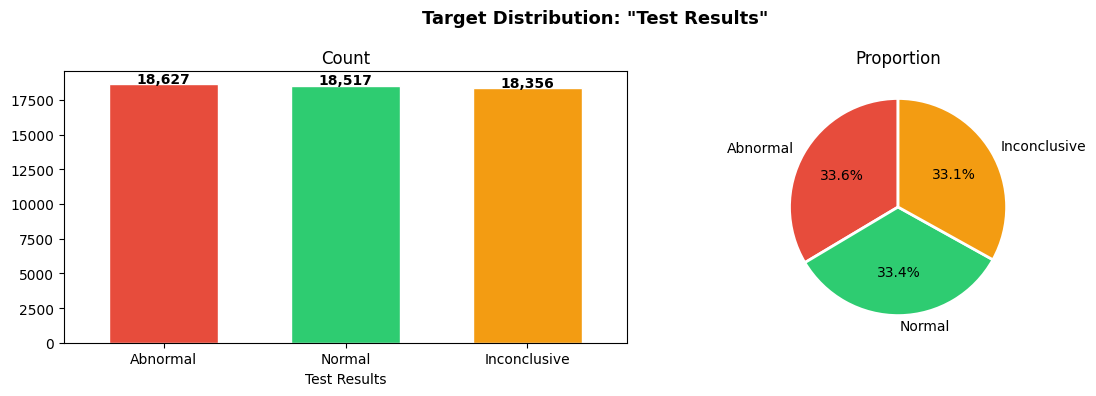

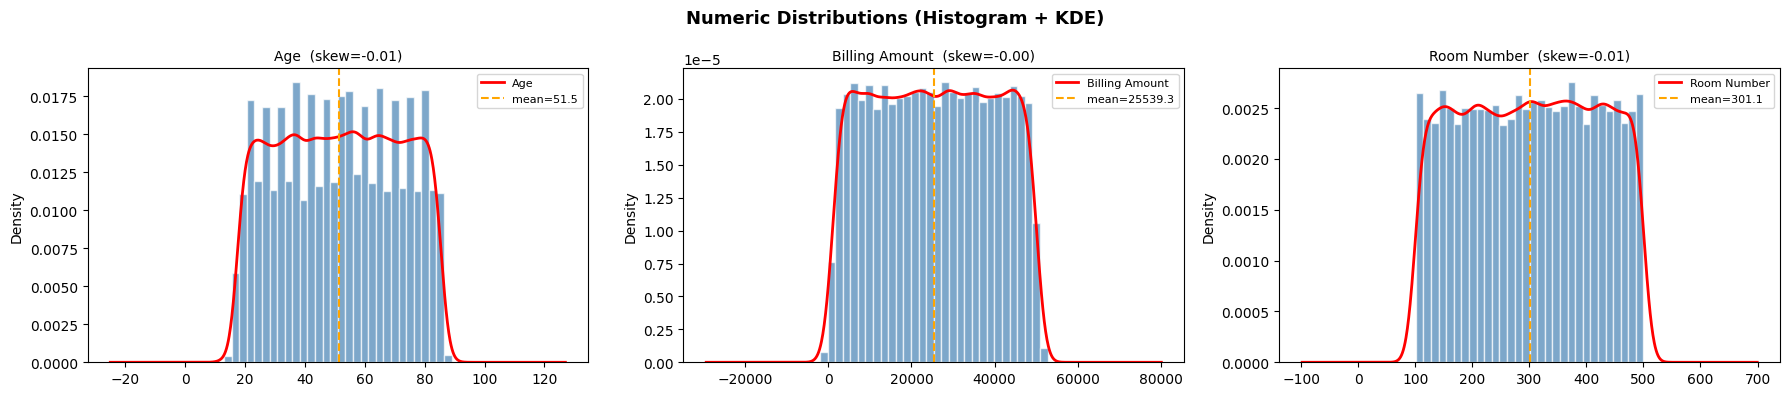

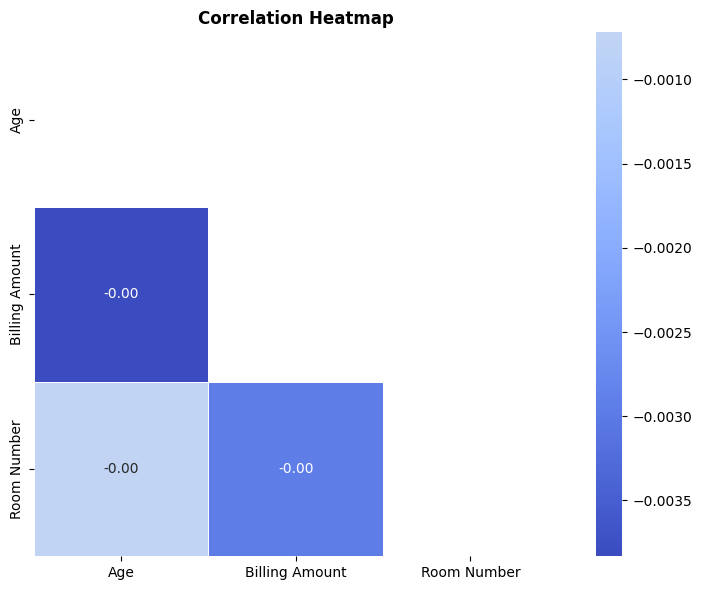

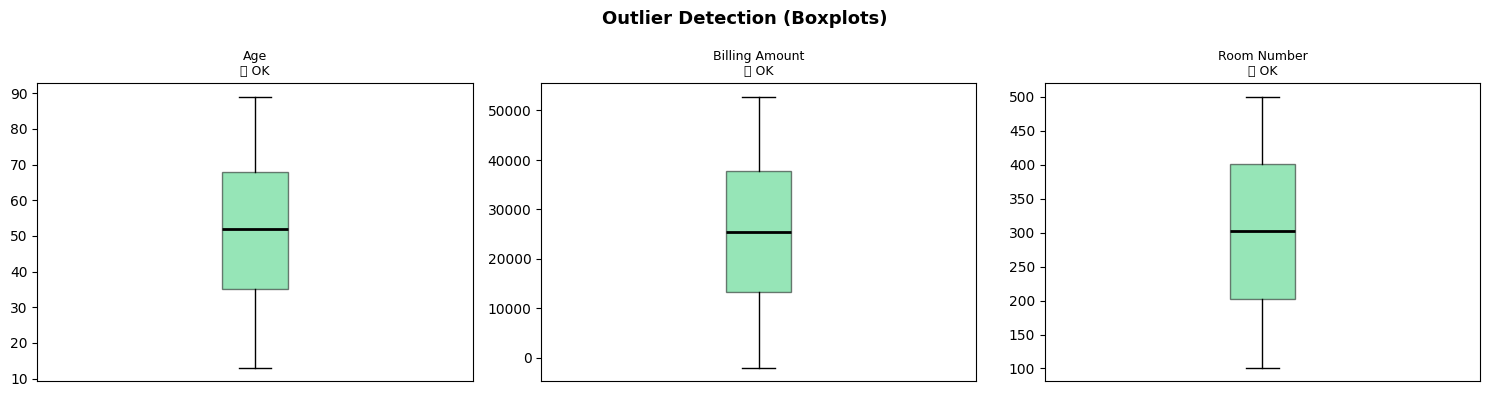

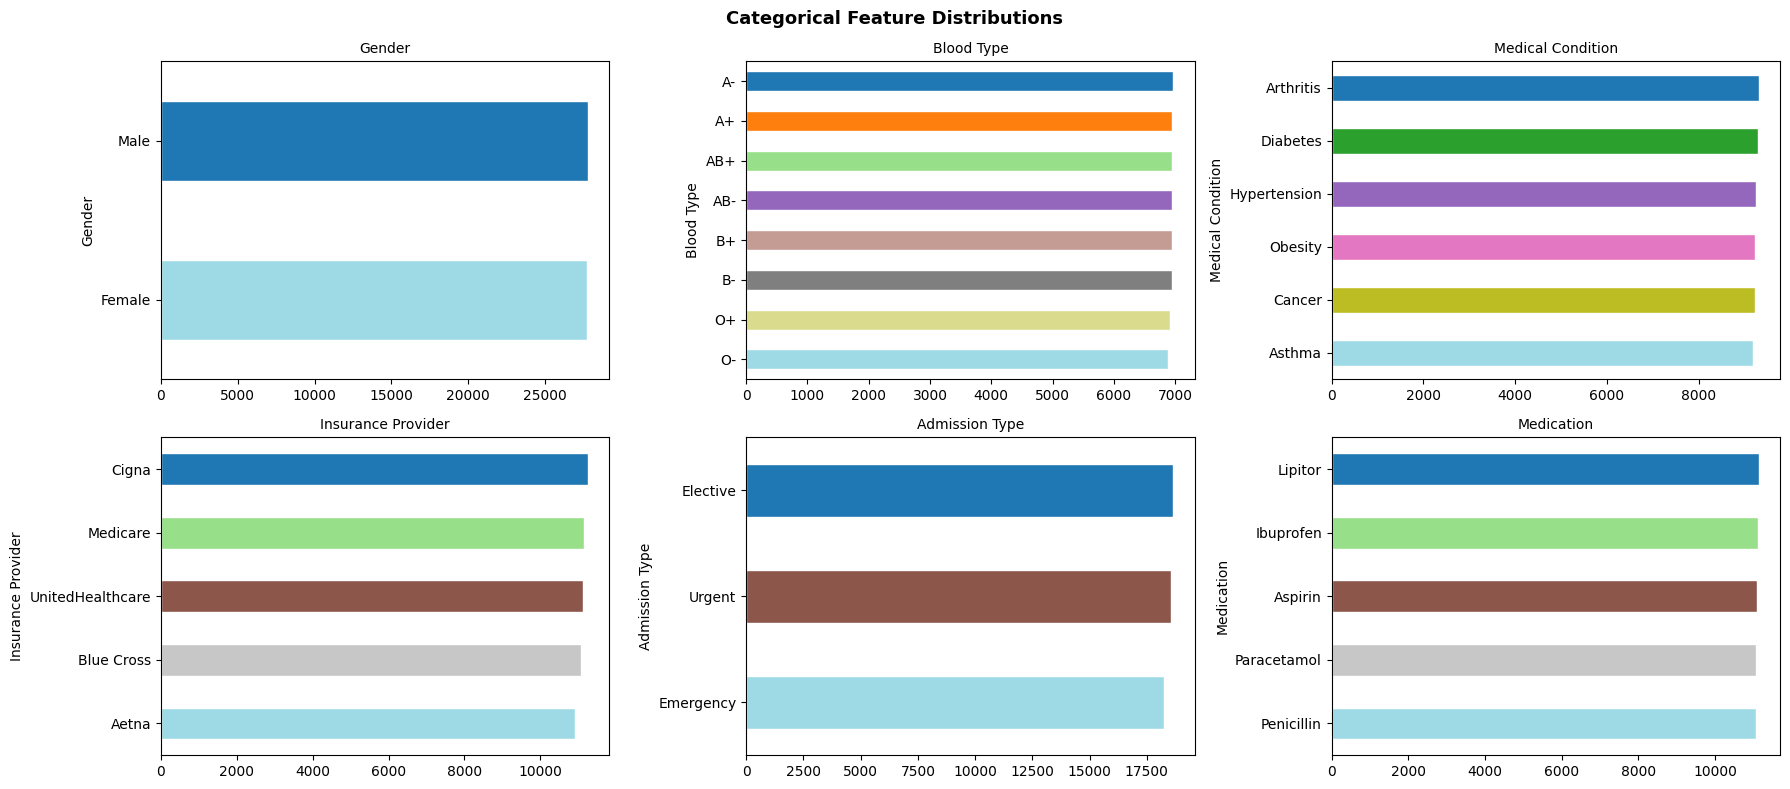

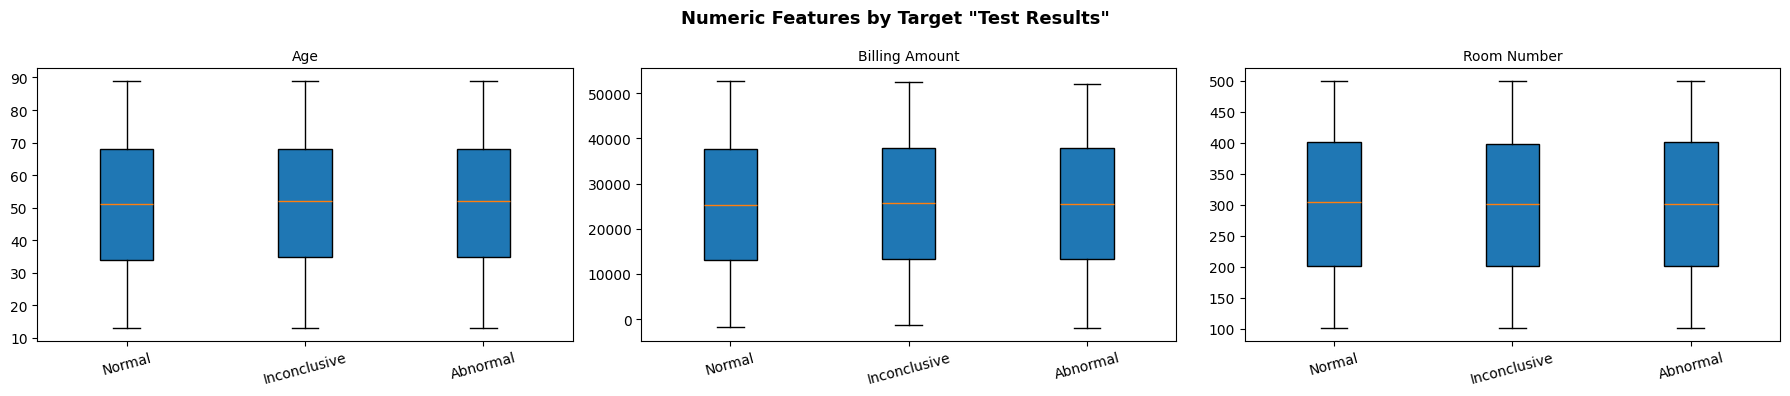

In [19]:
viz = AutoVisualizer(df, target_col='Test Results')
viz.run()

## 6. Tổng kết EDA

**Những vấn đề phát hiện:**
- `Billing Amount`: có 108 giá trị âm → cần `clip(lower=0)`
- `Name`, `Doctor`, `Hospital`: không có predictive power → cần drop
- 6 cột categorical → cần Label Encoding
- 2 cột datetime → cần trích xuất `Length of Stay`, `Month`, `DayOfWeek`
- Target 3 class cân bằng (~33% mỗi class) → không cần xử lý imbalance

